<a href="https://colab.research.google.com/github/DanielWill-1/Capstone-Project---using-Hybrid-Vision-Transformers-for-Diabetic-Retinopathy-Staging/blob/main/Untitled1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PyTorch version: 2.8.0+cu126
Device available: CPU
Initializing models...
Loading weights from /content/drive/MyDrive/Fundus_OCT_stuff/Weights...
All weights loaded successfully.

INSTRUCTIONS FOR INFERENCE
1. Go to the 'Files' tab on the left sidebar of Colab.
2. Navigate to the '/content/drive/MyDrive/Fundus_OCT_stuff/Weights' directory.
3. Upload your 5 model weights:
   - fundus_expert.pth
   - oct_expert.pth
   - fusion_module.pth
   - meta_dme.pth
   - meta_dr.pth

4. Navigate to the '/content/drive/MyDrive/Fundus_OCT_stuff/test images' directory.
5. Upload your test Fundus and OCT images.

6. Update the 'fundus_image_path' and 'oct_image_path' variables below.
7. Run this cell!

--- Prediction Results ---
Fundus Image: 0da09e3ce8f1.png
OCT Image:    1564_OI_o_1.jpg

--------------------------
DME Prediction: 0 (No DME)
Confidence:     98.56%
--------------------------
DR Prediction:  NPDR (Non-Proliferative DR)
Confidence:     99.88%
--------------------------


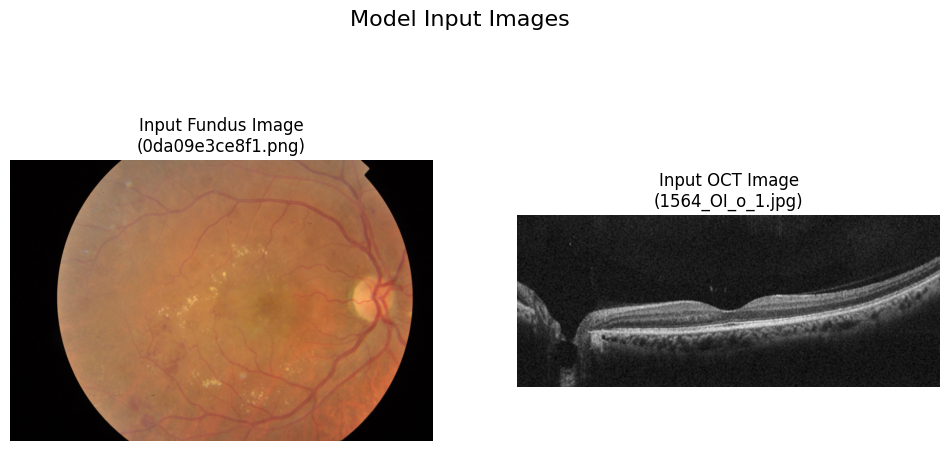

In [2]:
# ===================================================================
# 1. SETUP & IMPORTS
# ===================================================================
!pip install -q timm

import os
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"Device available: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

# ===================================================================
# 2. CONFIGURATION
# ===================================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DME_CLASSES = 2
DR_CLASSES = 3
IMG_SIZE = 224

# --- Define the paths for your files in Colab ---
# We will create these directories
WEIGHTS_DIR = Path("/content/drive/MyDrive/Fundus_OCT_stuff/Weights")
IMAGES_DIR = Path("/content/drive/MyDrive/Fundus_OCT_stuff/test images")
WEIGHTS_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(exist_ok=True)

# --- Define the inference image transform (from your validation set) ---
transform_inference = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- Define reverse mappings for human-readable output ---
DME_IDX_TO_LABEL = {
    0: "0 (No DME)",
    1: "1 (DME)"
}
DR_IDX_TO_LABEL = {
    0: "0 (No DR)",
    1: "NPDR (Non-Proliferative DR)",
    2: "PDR (Proliferative DR)"
}

# ===================================================================
# 3. MODEL DEFINITIONS
# (Must be EXACTLY as in your training script)
# ===================================================================

class HViT_Small(nn.Module):
    def __init__(self, backbone="efficientnet_b1", vit="vit_tiny_patch16_224", dme_classes=DME_CLASSES, dr_classes=DR_CLASSES):
        super().__init__()
        self.backbone = timm.create_model(backbone, pretrained=False, num_classes=0) # pretrained=False, we load weights
        self.vit = timm.create_model(vit, pretrained=False, num_classes=0) # pretrained=False, we load weights
        self.feat_dim = self.backbone.num_features + self.vit.num_features
        self.dropout = nn.Dropout(0.3)
        self.head_dme = nn.Linear(self.feat_dim, dme_classes)
        self.head_dr = nn.Linear(self.feat_dim, dr_classes)

    def forward(self, x):
        f1 = self.backbone(x)
        f2 = self.vit(x)
        feat = torch.cat([f1, f2], dim=1)
        feat = self.dropout(feat)
        out_dme = self.head_dme(feat)
        out_dr = self.head_dr(feat)
        return out_dme, out_dr, feat

class CrossAttentionFusion(nn.Module):
    def __init__(self, dim, dme_classes=DME_CLASSES, dr_classes=DR_CLASSES, heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True)
        self.fc_dme = nn.Linear(dim, dme_classes)
        self.fc_dr = nn.Linear(dim, dr_classes)
        self.dim = dim

    def forward(self, feat_fundus, feat_oct):
        q = feat_fundus.unsqueeze(1)
        kv = feat_oct.unsqueeze(1)
        fused, attn_weights = self.attn(q, kv, kv)
        fused = fused.squeeze(1)
        out_dme = self.fc_dme(fused)
        out_dr = self.fc_dr(fused)
        return out_dme, out_dr, fused

class MetaLearner(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(num_classes*3, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, p1, p2, p3):
        x = torch.cat([p1, p2, p3], dim=1)
        return self.mlp(x)

# ===================================================================
# 4. LOAD MODELS AND WEIGHTS
# ===================================================================

print("Initializing models...")
# 1. Instantiate all models
fundus_expert = HViT_Small().to(DEVICE)
oct_expert    = HViT_Small().to(DEVICE)
# Get feature dimension for fusion module
feat_dim = fundus_expert.feat_dim
fusion_module = CrossAttentionFusion(dim=feat_dim).to(DEVICE)
meta_dme      = MetaLearner(DME_CLASSES).to(DEVICE)
meta_dr       = MetaLearner(DR_CLASSES).to(DEVICE)

# 2. Define weight paths
WEIGHT_PATHS = {
    'fundus': WEIGHTS_DIR / "fundus_expert.pth",
    'oct': WEIGHTS_DIR / "oct_expert.pth",
    'fusion': WEIGHTS_DIR / "fusion_module.pth",
    'meta_dme': WEIGHTS_DIR / "meta_dme.pth",
    'meta_dr': WEIGHTS_DIR / "meta_dr.pth"
}

# 3. Load weights
try:
    print(f"Loading weights from {WEIGHTS_DIR}...")
    fundus_expert.load_state_dict(torch.load(WEIGHT_PATHS['fundus'], map_location=DEVICE))
    oct_expert.load_state_dict(torch.load(WEIGHT_PATHS['oct'], map_location=DEVICE))
    fusion_module.load_state_dict(torch.load(WEIGHT_PATHS['fusion'], map_location=DEVICE))
    meta_dme.load_state_dict(torch.load(WEIGHT_PATHS['meta_dme'], map_location=DEVICE))
    meta_dr.load_state_dict(torch.load(WEIGHT_PATHS['meta_dr'], map_location=DEVICE))
    print("All weights loaded successfully.")
except FileNotFoundError as e:
    print(f"\n---!!! ERROR: WEIGHT FILE NOT FOUND !!!---")
    print(f"Could not find file: {e.filename}")
    print(f"PLEASE UPLOAD YOUR 5 .pth FILES to the '{WEIGHTS_DIR}' directory in the Colab file explorer.")
    print("--------------------------------------------\n")

# 4. Set all models to evaluation mode (VERY IMPORTANT!)
fundus_expert.eval()
oct_expert.eval()
fusion_module.eval()
meta_dme.eval()
meta_dr.eval()

# Package models for convenience
models = {
    'fundus': fundus_expert,
    'oct': oct_expert,
    'fusion': fusion_module,
    'meta_dme': meta_dme,
    'meta_dr': meta_dr
}

# ===================================================================
# 5. INFERENCE FUNCTION
# ===================================================================

def predict(fundus_img_path, oct_img_path, models_dict, transform, device):
    """
    Runs a single prediction on a pair of fundus and OCT images.
    """
    try:
        # 1. Load and transform images
        f_img = Image.open(fundus_img_path).convert("RGB")
        o_img = Image.open(oct_img_path).convert("RGB")

        f_img_t = transform(f_img).unsqueeze(0).to(device) # Add batch dim [1, C, H, W]
        o_img_t = transform(o_img).unsqueeze(0).to(device) # Add batch dim [1, C, H, W]

    except FileNotFoundError as e:
        print(f"\n---!!! ERROR: IMAGE FILE NOT FOUND !!!---")
        print(f"Could not find file: {e.filename}")
        print(f"PLEASE UPLOAD YOUR 2 image files to the '{IMAGES_DIR}' directory.")
        print("--------------------------------------------\n")
        return None, (None, None)

    # 2. Run the full forward pass (no gradients needed)
    with torch.no_grad():
        p_f_dme, p_f_dr, feat_f = models_dict['fundus'](f_img_t)
        p_o_dme, p_o_dr, feat_o = models_dict['oct'](o_img_t)

        p_fu_dme, p_fu_dr, feat_fu = models_dict['fusion'](feat_f, feat_o)

        p_meta_dme = models_dict['meta_dme'](p_f_dme, p_o_dme, p_fu_dme)
        p_meta_dr = models_dict['meta_dr'](p_f_dr, p_o_dr, p_fu_dr)

    # 3. Get probabilities and predictions

    # --- DME ---
    dme_probs = F.softmax(p_meta_dme, dim=1)
    dme_confidence, dme_pred_idx = torch.max(dme_probs, dim=1)
    dme_pred_label = DME_IDX_TO_LABEL[dme_pred_idx.item()]

    # --- DR ---
    dr_probs = F.softmax(p_meta_dr, dim=1)
    dr_confidence, dr_pred_idx = torch.max(dr_probs, dim=1)
    dr_pred_label = DR_IDX_TO_LABEL[dr_pred_idx.item()]

    results = {
        "dme_prediction": dme_pred_label,
        "dme_confidence": dme_confidence.item(),
        "dr_prediction": dr_pred_label,
        "dr_confidence": dr_confidence.item()
    }

    return results, (f_img, o_img)

# ===================================================================
# 6. RUN PREDICTION
# ===================================================================

print("\n" + "="*50)
print("INSTRUCTIONS FOR INFERENCE")
print("="*50)
print(f"1. Go to the 'Files' tab on the left sidebar of Colab.")
print(f"2. Navigate to the '{WEIGHTS_DIR}' directory.")
print(f"3. Upload your 5 model weights:")
print("   - fundus_expert.pth")
print("   - oct_expert.pth")
print("   - fusion_module.pth")
print("   - meta_dme.pth")
print("   - meta_dr.pth")
print(f"\n4. Navigate to the '{IMAGES_DIR}' directory.")
print(f"5. Upload your test Fundus and OCT images.")
print(f"\n6. Update the 'fundus_image_path' and 'oct_image_path' variables below.")
print("7. Run this cell!")
print("="*50 + "\n")


# ---- !!! UPDATE THESE PATHS !!! ----
fundus_image_path = '/content/drive/MyDrive/Fundus_OCT_stuff/test images/fundus_NPDR/0da09e3ce8f1.png'
oct_image_path    = '/content/drive/MyDrive/Fundus_OCT_stuff/test images/oct/1564_OI_o_1.jpg'
# ------------------------------------


# Run the prediction
results, (f_img_pil, o_img_pil) = predict(fundus_image_path, oct_image_path, models, transform_inference, DEVICE)

# Print results
if results:
    print("--- Prediction Results ---")
    print(f"Fundus Image: {os.path.basename(fundus_image_path)}")
    print(f"OCT Image:    {os.path.basename(oct_image_path)}")
    print("\n" + "-"*26)
    print(f"DME Prediction: {results['dme_prediction']}")
    print(f"Confidence:     {results['dme_confidence']:.2%}")
    print("-"*26)
    print(f"DR Prediction:  {results['dr_prediction']}")
    print(f"Confidence:     {results['dr_confidence']:.2%}")
    print("-"*26)

    # Show the images
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].imshow(f_img_pil)
    ax[0].set_title(f"Input Fundus Image\n({os.path.basename(fundus_image_path)})")
    ax[0].axis('off')

    ax[1].imshow(o_img_pil)
    ax[1].set_title(f"Input OCT Image\n({os.path.basename(oct_image_path)})")
    ax[1].axis('off')

    plt.suptitle("Model Input Images", fontsize=16)
    plt.show()